# Aircraft Engine RUL Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [2]:
df = pd.read_csv("train_cleaned_data.csv")
f=[]
for col in df.columns:
    if col not in ["UnitNumber", "RUL"]:
        f.append(col)
X = df[f]
y = df["RUL"]

In [3]:
scaler = MinMaxScaler()
scaled_x= scaler.fit_transform(X)

In [4]:
def sequences(X, y, window_size=20):
    seq_x, seq_y = [], []

    for i in range(len(X) - window_size):
        seq_x.append(X[i:i+window_size])
        seq_y.append(y.iloc[i+window_size])

    return np.array(seq_x), np.array(seq_y)

Xs,Ys=sequences(pd.DataFrame(scaled_x), y)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(Xs, Ys, test_size=0.2, random_state=42)

In [6]:
m= Sequential()
m.add(LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2])))
m.add(Dense(32, activation='relu'))
m.add(Dense(1))
m.compile(optimizer='adam', loss='mse')

c:\Users\umesh\anaconda3\envs\data_env\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
history = m.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 7185.1797 - val_loss: 4837.6821
Epoch 2/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 4526.8584 - val_loss: 2795.7795
Epoch 3/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 1955.5829 - val_loss: 1723.2150
Epoch 4/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 1653.0449 - val_loss: 1581.3070
Epoch 5/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 1620.9601 - val_loss: 1594.1307
Epoch 6/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 1562.4553 - val_loss: 1549.6549
Epoch 7/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 1549.3010 - val_loss: 1652.8860
Epoch 8/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 1533.1760 - val_loss: 1506.1449
Epoch 9/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 1492.6786 - val_loss: 1502.5002
Epoch 10/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 1469.3273 - val_loss: 1536.6340
Epoch 11/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 1435.00

In [8]:
y_pred = m.predict(X_test).flatten()

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 25.37683868408203
RMSE: 36.88863624986698
MSE: 1360.771484375
R2 Score: 0.7073123455047607


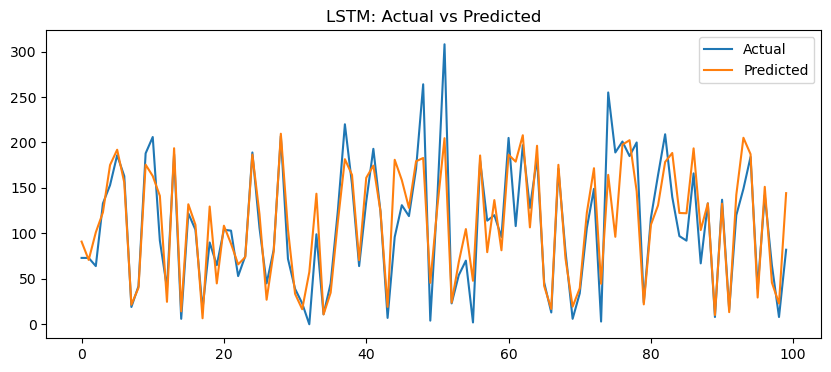

In [10]:
plt.figure(figsize=(10,4))
plt.plot(y_test[:100], label="Actual")
plt.plot(y_pred[:100], label="Predicted")
plt.legend()
plt.title("LSTM: Actual vs Predicted")
plt.show()

LSTM achieved higher R² because it captures temporal dependencies in sensor data across cycles, whereas XGBoost treats each observation independently